In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Read the data from csv
df_subject = pd.read_csv('subject-info.csv')
df_test = pd.read_csv('test_measure.csv')

#Exclude warm up phase
df_test_excludewarmup =df_test[ df_test['Speed'] > 5].copy()

#Merge 2 datsets on participant ID
df_merge = pd.merge(df_subject,df_test, on='ID')

In [3]:
#Q.1 Performance Consistency: Identify athletes whose heart rate (HR) varies the least during the entire test.

# Extract base ID from ID_test (everything before the underscore)
df_test_excludewarmup['Athlete_ID'] = df_test_excludewarmup['ID_test'].apply(lambda x: x.split('_')[0])

# Standard deviation of HR per athlete
hr_variation = df_test_excludewarmup.groupby(['Athlete_ID'])['HR'].std().reset_index()
hr_variation.columns = ['Athlete_ID', 'HR_StdDev']

# Round to 2 decimal places
hr_variation['HR_StdDev'] = hr_variation['HR_StdDev'].round(2)

# Sort by least variation, Lower the STD = more consistent
least_hr = hr_variation.sort_values('HR_StdDev')

display(least_hr.style.hide(axis='index').format({'HR_StdDev': '{:.1f}'}))


Athlete_ID,HR_StdDev
817,6.0
144,9.1
486,9.2
645,10.2
9,11.8
246,11.9
414,12.1
213,12.2
318,12.7
250,12.9


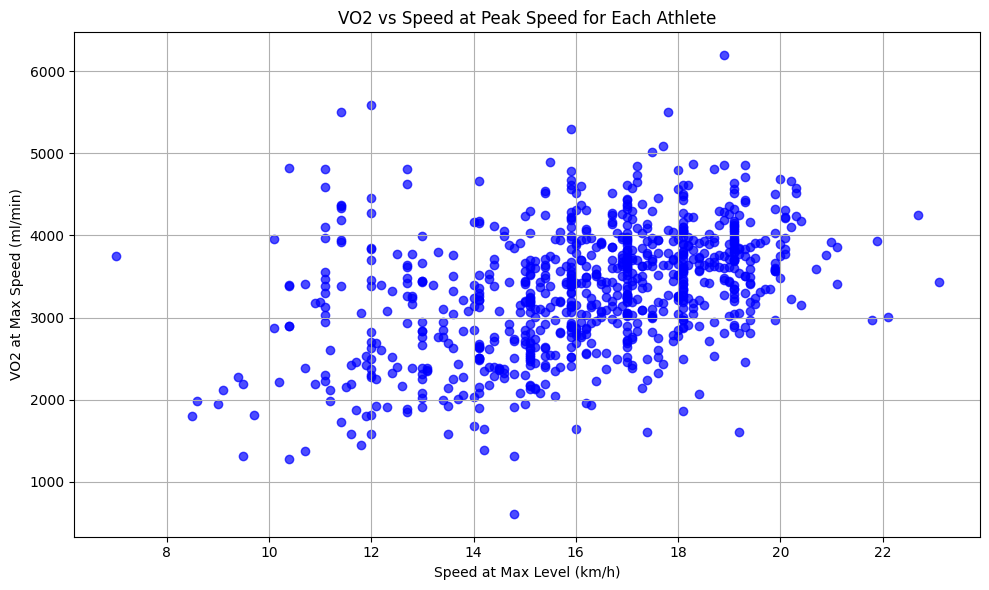

In [4]:
#Q2. Efficiency at Peak Speed: Identify the efficiency (VO2 and VE) at peak speed for each athlete.

# Get the rows where Speed is maximum for each ID
df_peak_speed_data = df_test.loc[df_test.groupby('ID')['Speed'].idxmax()].copy()


plt.figure(figsize=(10, 6))
plt.scatter(df_peak_speed_data['Speed'], df_peak_speed_data['VO2'], color='blue', alpha=0.7)
plt.title('VO2 vs Speed at Peak Speed for Each Athlete')
plt.xlabel('Speed at Max Level (km/h)')
plt.ylabel('VO2 at Max Speed (ml/min)')
plt.grid(True)
plt.tight_layout()
plt.show()


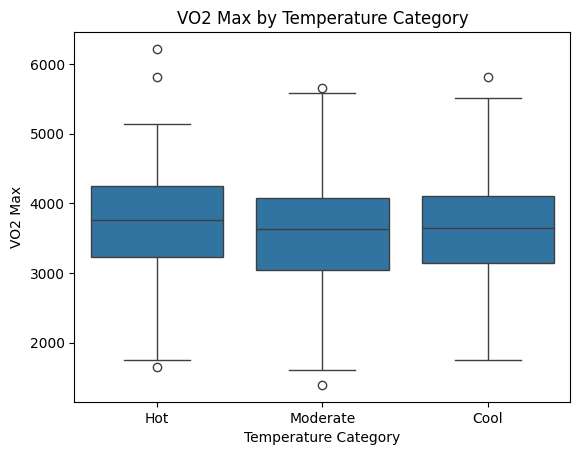

In [5]:
#Q.3 Categorize by Temperature and Compare VO2 Max
#(Assumption: Temp < 20°C = Cool, 20-25 = Moderate, >25 = Hot.)



# Create temperature categories
def categorize_temp(temp):
    if temp < 20:
        return 'Cool'
    elif 20 <= temp <= 25:
        return 'Moderate'
    else:
        return 'Hot'

df_subject['Temp_Category'] = df_subject['Temperature'].apply(categorize_temp).copy()

test_temp_category = pd.merge(df_test, df_subject[['ID', 'Temp_Category']], on='ID')

# Max VO2 per test
vo2_max = test_temp_category.groupby(['ID', 'Temp_Category'])['VO2'].max().reset_index()

# Plot
sns.boxplot(data=vo2_max, x='Temp_Category', y='VO2')
plt.title('VO2 Max by Temperature Category')
plt.xlabel('Temperature Category')
plt.ylabel('VO2 Max')
plt.show()


In [ ]:
#Q4)What is the average treadmill speed for each athlete. Display Top 5 athletes with highest average rate?

avg_hr_per_athlete = df_test.groupby('ID')['HR'].mean()

# Top 5 athletes with highest avg HR
top_athletes = avg_hr_per_athlete.sort_values(ascending=False).head(5)
print("Top 5 Athletes with Highest Average Heart Rate:")
print(top_athletes)

Top 5 Athletes with Highest Average Heart Rate:
ID
647    178.164894
589    176.876206
441    176.542035
204    175.556492
87     174.822222
Name: HR, dtype: float64


In [ ]:
#BMI Analysis
#Convert height from cm to meters
df_subject['Height_m'] = df_subject['Height'] / 100

#BMI
df_subject['BMI'] = df_subject['Weight'] / (df_subject['Height_m'] ** 2)

#calculate ideal weight
ideal_bmi = 22
df_subject['Ideal_weight'] = ideal_bmi * (df_subject['Height_m'] ** 2)

#weight difference
df_subject['Weight_diff'] = df_subject['Weight'] - df_subject['Ideal_weight']

#BMI Levels
def bmi_levels(bmi):
    if bmi < 18.5:
        return 'underweight'
    elif bmi < 25:
        return 'normal'
    elif bmi < 30:
        return 'overweight'
    else:
        return 'obese'

df_subject['BMI_level'] = df_subject['BMI'].apply(bmi_levels)

#merge on ID
df_merge = pd.merge(df_test, df_subject, on='ID')

#df_subject[['ID', 'Weight', 'Ideal_weight', 'Weight_diff', 'BMI_level']].head()


In [10]:
#Q5)How far is each BMI level from ideal weight on an average?

#Group by BMI level to calculate average weight difference
avg_weight_diff = df_subject.groupby('BMI_level')['Weight_diff'].mean()
print("Average weight difference from ideal weight as per BMI levels:")
print(avg_weight_diff.round(2))


Average weight difference from ideal weight as per BMI levels:
BMI_level
normal          2.18
obese          36.18
overweight     14.30
underweight   -11.53
Name: Weight_diff, dtype: float64


In [ ]:
#Q6)Which BMI level needs the most effort to reach ideal weight?

# BMI Level with highest absolute weight difference
most_effort_group = avg_weight_diff.abs().idxmax()
most_effort_value = avg_weight_diff[most_effort_group]

print(f"\nGroup needing the most effort: {most_effort_group} ({round(most_effort_value, 2)} kg)")



Group needing the most effort: obese (36.18 kg)


In [ ]:
#Q7) What % of each BMI group is above/below ideal weight?

#Classify if athlete is above or below ideal
df_subject['Weight_category'] = df_subject['Weight_diff'].apply(lambda x: 'Above_ideal' if x > 0 else 'Below_ideal')

# Count per BMI Level
weight_percent = df_subject.groupby(['BMI_level', 'Weight_category']).size().unstack(fill_value=0)

# Convert to %
weight_percent = weight_percent.div(weight_percent.sum(axis=1), axis=0) * 100

print("Percentage of athletes above/below ideal weight per BMI group:")
print(weight_percent.round(2))


Percentage of athletes above/below ideal weight per BMI group:
Weight_category  Above_ideal  Below_ideal
BMI_level                                
normal                 69.55        30.45
obese                 100.00         0.00
overweight            100.00         0.00
underweight             0.00       100.00


 Signed Weight Adjustment (kg):
Normal: Needs to GAIN 1461.37 kg total
Obese: Needs to GAIN 904.42 kg total
Overweight: Needs to GAIN 3845.65 kg total
Underweight: Needs to LOSE 322.89 kg total

 Total Effort Needed (kg, absolute):
bmi_level
normal         2916.37
obese           904.42
overweight     3845.65
underweight     322.89
Name: weight_diff, dtype: float64


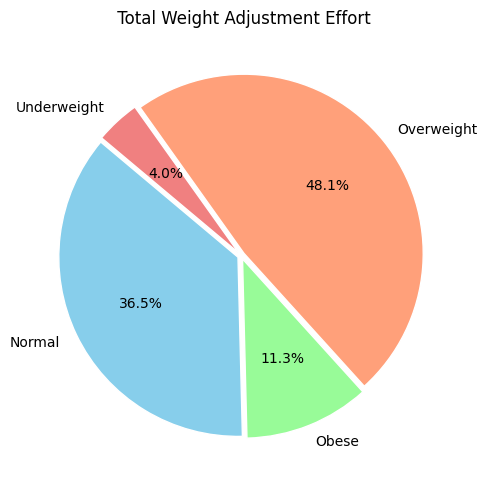

In [ ]:
#Q8) Total weight to gain/lose per BMI level (signed and absolute)?

#group analysis:Total signed & absolute weight difference per BMI level
total_signed = df_subject.groupby('bmi_level')['weight_diff'].sum() #Do they need to lose or gain?
total_absolute = df_subject.groupby('bmi_level')['weight_diff'].apply(lambda x: x.abs().sum()) #What’s the total effort needed

#summary
print(" Signed Weight Adjustment (kg):")
for level, value in total_signed.items():
    if value < 0:
        print(f"{level.title()}: Needs to LOSE {abs(round(value, 2))} kg total")
    elif value > 0:
        print(f"{level.title()}: Needs to GAIN {round(value, 2)} kg total")
    else:
        print(f"{level.title()}: Already at ideal weight")

print("\n Total Effort Needed (kg, absolute):")
print(total_absolute.round(2))

#pie chart
plt.figure(figsize=(5, 5))  
colors = ['skyblue', 'palegreen', 'lightsalmon', 'lightcoral']
explode = [0.02]*len(total_absolute)  
plt.pie(total_absolute,
        labels=total_absolute.index.str.title(),
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        explode=explode,
        wedgeprops={'linewidth': 1, 'edgecolor': 'white'},
        textprops={'fontsize': 10})

plt.title(" Total Weight Adjustment Effort", fontsize=12)
plt.axis('equal')  # keep it circular
plt.tight_layout()
plt.show()